# 한강공원 쓰레기 발생량과 한강 공원 근처 지하철 이용객 수의 관계


In [1]:
# 1. 한글 폰트
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# 3. 한글 폰트 지정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐

from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/AI+X/'

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,700 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126675 files and dire

In [2]:
# 데이터 인코딩
trash = pd.read_csv('/content/drive/MyDrive/AI+X/한강공원 쓰레기 발생량.csv', encoding='cp949')
subway_raw = pd.read_csv('/content/drive/MyDrive/AI+X/subway_raw.csv', encoding='utf-8')
station_info = pd.read_csv('/content/drive/MyDrive/AI+X/지하철노선위경도정보2.csv', encoding='utf-8')
park_info = pd.read_csv('/content/drive/MyDrive/AI+X/hangangrv_park_location.csv', skiprows=1, encoding='cp949')

In [3]:
park_info.columns = ['park_name', 'park_area', 'lon', 'lat', 'collect_date']
park_info = park_info[['park_name', 'lat', 'lon']] # 필요한 컬럼만 선택
park_info['park_name'] = park_info['park_name'].str.replace('한강공원', '').str.strip()

station_info.columns = ['station_name', 'region', 'lat', 'lon', 'line']
station_info = station_info[station_info['region'] == '수도권']

subway_raw.columns = ['date', 'day_of_week', 'line', 'station_name', 'riders', 'alighters', 'total_passengers', 'year_month_str', 'month_day_str', 'registered_date']
subway_raw['date'] = pd.to_datetime(subway_raw['date'])
subway_raw['year'] = subway_raw['date'].dt.year
subway_raw['month'] = subway_raw['date'].dt.month

# ---  분석 기간(2019년 1월~6월)에 맞게 데이터를 필터링 ---
TARGET_YEAR = 2019
MONTHS = [1, 2, 3, 4, 5, 6]

# 쓰레기 데이터 필터링
trash_filtered = trash[trash['연도'] == TARGET_YEAR].copy()
month_cols = [f'{m}월' for m in MONTHS]
trash_final = trash_filtered[['연도'] + month_cols]

# 지하철 데이터 필터링
subway_final = subway_raw[
    (subway_raw['year'] == TARGET_YEAR) &
    (subway_raw['month'].isin(MONTHS))
].copy()

print(f"분석 대상 기간: {TARGET_YEAR}년 {MONTHS[0]}월 ~ {MONTHS[-1]}월")

display(park_info)
display(station_info)
display(trash_final)
display(subway_final)

분석 대상 기간: 2019년 1월 ~ 6월


,park_name,lat,lon
0,광나루,37.54894,127.1201
1,잠실,37.51765,127.0867
2,뚝섬,37.52952,127.0700
3,잠원,37.51916,127.0093
4,반포,37.51075,126.9960
5,이촌,37.51703,126.9717
6,여의도,37.52687,126.9347
7,양화,37.53847,126.9023
8,난지,37.56619,126.8765
9,망원,37.55552,126.8949


,station_name,region,lat,lon,line
0,낙성대,수도권,37.477090,126.963506,2호선
1,구룡,수도권,37.487027,127.059475,분당선
2,서울대입구,수도권,37.481285,126.952695,2호선
3,불광,수도권,37.610044,126.930302,3호선
4,월롱,수도권,37.796204,126.792563,경의선
...,...,...,...,...,...
723,종각,수도권,37.570222,126.983134,1호선
724,화계,수도권,37.634084,127.017492,우이신설경전철
725,삼양,수도권,37.626912,127.018148,우이신설경전철
726,회기,수도권,37.589778,127.058039,경의선


,연도,1월,2월,3월,4월,5월,6월
4,2019,21,169,154,326,555,388


,date,day_of_week,line,station_name,riders,alighters,total_passengers,year_month_str,month_day_str,registered_date,year,month
0,2019-02-01,금,6호선,이태원,15786,21324,37110,Feb-19,02월 01일,20190204,2019,2
1,2019-02-01,금,6호선,한강진,9085,10665,19750,Feb-19,02월 01일,20190204,2019,2
2,2019-02-01,금,6호선,버티고개,2660,2486,5146,Feb-19,02월 01일,20190204,2019,2
3,2019-02-01,금,3호선,약수,4245,4396,8641,Feb-19,02월 01일,20190204,2019,2
4,2019-02-01,금,5호선,청구,4236,4612,8848,Feb-19,02월 01일,20190204,2019,2
...,...,...,...,...,...,...,...,...,...,...,...,...
107023,2019-04-30,화,1호선,종로5가,32828,33182,66010,Apr-19,04월 30일,20190503,2019,4
107024,2019-04-30,화,3호선,종로3가,37628,35721,73349,Apr-19,04월 30일,20190503,2019,4
107025,2019-04-30,화,1호선,종각,51823,50610,102433,Apr-19,04월 30일,20190503,2019,4
107026,2019-04-30,화,2호선,시청,32485,32917,65402,Apr-19,04월 30일,20190503,2019,4


In [4]:
# 위도, 경도로 두 지점 간의 거리를 계산하는 함수 (Haversine formula)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # 지구의 반지름 (km)
    dLat = np.radians(lat2 - lat1)
    dLon = np.radians(lon2 - lon1)
    a = np.sin(dLat / 2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dLon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# 각 공원별로 1.7km 이내의 지하철역 목록 -> 최소한 하나의 한강 공원이 하나의 지하철 역을 가지는 거리
park_stations = {}
for _, park in park_info.iterrows():
    nearby_stations = []
    for _, station in station_info.iterrows():
        distance = haversine(park['lat'], park['lon'], station['lat'], station['lon'])
        if distance <= 1.7:
            nearby_stations.append(station['station_name'])
    park_stations[park['park_name']] = list(set(nearby_stations))


display(park_stations)

{'광나루': ['천호', '광나루', '암사'],
 '잠실': ['종합운동장', '잠실', '잠실새내', '잠실나루', '삼전'],
 '뚝섬': ['건대입구', '구의', '뚝섬유원지'],
 '잠원': ['논현', '신사', '한남', '잠원', '고속터미널', '반포'],
 '반포': ['구반포', '잠원', '서빙고', '고속터미널', '신반포', '반포', '동작'],
 '이촌': ['이촌', '신용산', '서빙고', '흑석', '용산'],
 '여의도': ['여의도', '여의나루', '대방', '샛강', '노량진', '국회의사당'],
 '양화': ['당산', '선유도', '합정', '영등포구청'],
 '난지': ['증미'],
 '망원': ['신목동', '망원', '월드컵경기장', '마포구청'],
 '강서': ['방화']}

In [5]:
# 1. 공원 근처 모든 지하철역의 목록을 하나로 합치기
nearby_station_list = list(set(station for stations in park_stations.values() for station in stations))

# 2. 이 역들의 월별 총 승하차객 수를 계산하기
monthly_subway_nearby = subway_final[subway_final['station_name'].isin(nearby_station_list)]
monthly_subway_total = monthly_subway_nearby.groupby('month')['total_passengers'].sum().reset_index()

# 3. 쓰레기 데이터를 월별로 정리된 형태로 변환
trash_melted = trash_final.melt(id_vars=['연도'], var_name='월', value_name='trash_amount')
trash_melted['month'] = trash_melted['월'].str.replace('월', '').astype(int)

# 4. 월을 기준으로 쓰레기 데이터와 지하철 데이터를 합치기
merged = pd.merge(trash_melted, monthly_subway_total, on='month')
merged = merged[['month', 'trash_amount', 'total_passengers']] # 최종 분석용 컬럼 선택

display(merged)

,month,trash_amount,total_passengers
0,1,21,54792726
1,2,169,47523035
2,3,154,56427553
3,4,326,58219961
4,5,555,59893977
5,6,388,54300490


In [6]:
# 피어슨 상관계수 (선형 관계 측정)
pearson_corr, p_value_p = pearsonr(merged['trash_amount'], merged['total_passengers'])

# 스피어만 상관계수 (순위 기반의 비모수 검정)
spearman_corr, p_value_s = spearmanr(merged['trash_amount'], merged['total_passengers'])

print("---  상관 분석 결과 (2019년 1월 ~ 6월) ---")
print(f"피어슨 상관계수: {pearson_corr:.4f} (p-value: {p_value_p:.4f})")
print(f"스피어만 상관계수: {spearman_corr:.4f} (p-value: {p_value_s:.4f})")

---  상관 분석 결과 (2019년 1월 ~ 6월) ---
피어슨 상관계수: 0.5174 (p-value: 0.2931)
스피어만 상관계수: 0.3714 (p-value: 0.4685)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50416 (\N{HANGUL SYLLABLE SSEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

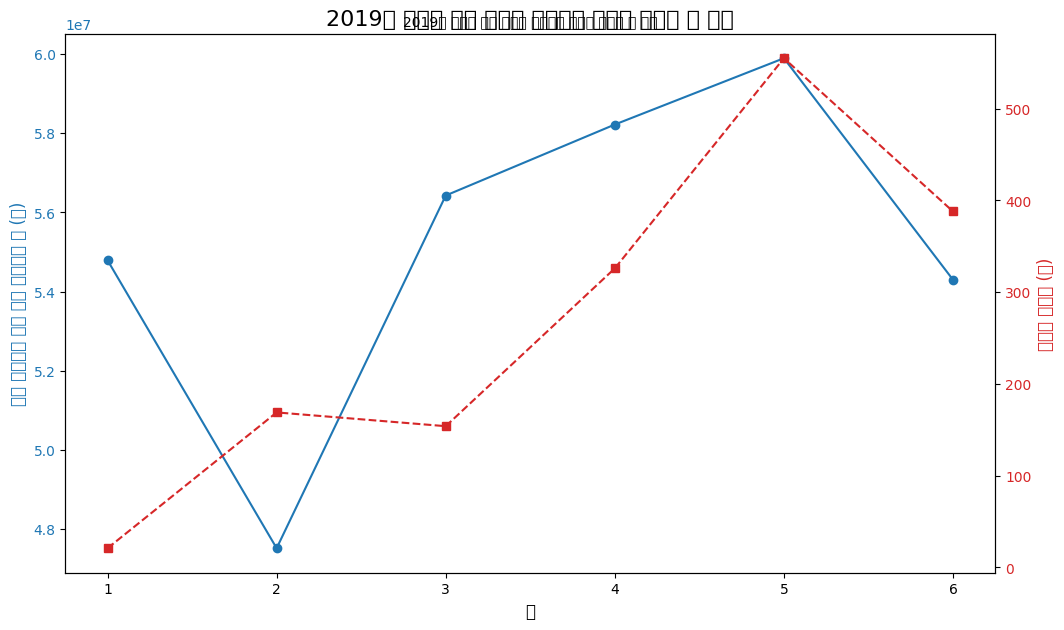

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


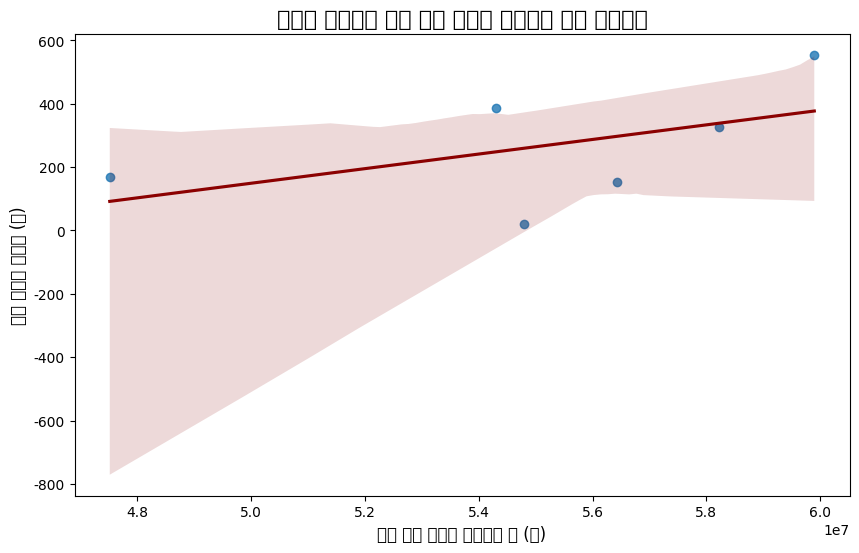

In [7]:
merged = merged.copy()

# --- 시각화 1: 월별 쓰레기 발생량 & 지하철 이용객 수 추세 ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# 첫 번째 Y축 (지하철 이용객 수)
color = 'tab:blue'
ax1.set_xlabel('월', fontsize=12)
ax1.set_ylabel('주변 지하철역 월별 평균 승하차객 수 (명)', color=color, fontsize=12)
ax1.plot(merged['month'], merged['total_passengers'], color=color, marker='o', label='지하철 이용객 수')
ax1.tick_params(axis='y', labelcolor=color)

ax1.set_xlabel('월', fontsize=12, fontproperties='NanumGothic')
ax1.set_ylabel('주변 지하철역 월별 평균 승하차객 수 (명)', color=color, fontsize=12, fontproperties='NanumGothic')
ax1.set_title('2019년 상반기 월별 쓰레기 발생량과 지하철 이용객 수 추세', fontsize=16, fontproperties='NanumGothic')


# 두 번째 Y축 (쓰레기 발생량)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('쓰레기 발생량 (톤)', color=color, fontsize=12)
ax2.plot(merged['month'], merged['trash_amount'], color=color, marker='s', linestyle='--', label='쓰레기 발생량')
ax2.tick_params(axis='y', labelcolor=color)

ax2.set_ylabel('쓰레기 발생량 (톤)', color=color, fontsize=12, fontproperties='NanumGothic')


plt.title('2019년 상반기 월별 쓰레기 발생량과 지하철 이용객 수 추세', fontsize=16)
plt.show()


# --- 시각화 2: 상관관계 산점도 ---
plt.figure(figsize=(10, 6))
# Use merged instead of merged, and total_avg_ridership instead of total_passengers
sns.regplot(data=merged, x='total_passengers', y='trash_amount', line_kws={"color": "darkred"})
plt.title('쓰레기 발생량과 월별 평균 지하철 승하차객 수의 상관관계', fontsize=16)
plt.xlabel('월별 평균 지하철 승하차객 수 (명)', fontsize=12)
plt.ylabel('월별 쓰레기 발생량 (톤)', fontsize=12)
plt.show()

# 결과

## 분석 목표
2019년 (1월~6월)의 지하철 이용데이터와 역 위치 데이터, 한강 공원 위치 데이터, 한강 공원 쓰레기 발생량 데이터를 활용하여 한강공원의 쓰레기 발생량과 공원 주변 지하철역 이용객 수 사이에 관계가 있는지 파악하는 것을 목표로 하였습니다.

## 자료 분석
1. 월별 변화 추이 분석
2019년 상반기 동안 월별 쓰레기 발생량과 주변 지하철역의 총 승하차객 수는 일부 시각적으로 유사한 증가 패턴을 보였습니다.

2. 상관관계 분포 분석
월별 지하철 이용객 수(X축)와 쓰레기 발생량(Y축)의 관계를 산점도로 시각화한 결과, 데이터 포인트들은 전반적으로 우상향하는 경향을 보여 두 변수 사이에 양(+)의 관계가 있음을 보여주지만 일부 데이터 포인트가 추세선에서 다소 떨어져 있어 관계의 강도가 매우 높지는 않을 수 있음을 알 수 있었습니다.

### 통계적 상관 분석 결과
+ 피어슨 상관계수: 0.5174 (p-value: 0.2931)

+ 스피어만 상관계수: 0.3714 (p-value: 0.4685)

상관 분석 결과, 두 변수 간에는 약한 양의 상관관계(0.37 ~ 0.51)가 있는 것으로 나타났으나 p-value가 통계적 유의성 판단의 기준인 0.05보다 매우 높은 0.29와 0.46으로 측정되었다. 이는 관찰된 약한 양의 상관관계가 통계적으로 유의미하지 않으며, 우연에 의해 발생했을 가능성이 매우 높다는 것을 의미함을 알게되었습니다.

최종 결론
2019년 상반기 데이터를 분석한 결과, 한강공원 쓰레기 발생량과 주변 지하철 이용객 수 사이에는 시각적으로 유사한 증가 패턴이 관찰되었으나, 통계적으로 유의미한 상관관계는 발견되지 않았습니다.

따라서 '지하철 이용객 수가 증가하면 쓰레기 발생량도 증가한다'는 가설을 뒷받침하기 어렵다고 결론 지었습니다. 한강공원의 쓰레기 문제는 지하철 이용객 수라는 단일 요인으로는 영향을 미치지 못했음을 알 수 있었습니다.